# MNIST Clustering — Model Comparison

This notebook runs inference using all pre-trained models on the MNIST dataset and compares their clustering performance.

**Models**: Baseline GMM, VAE-GMM, Diffusion-VAE, Ours  
**Metrics**: Accuracy (Hungarian), NMI, ARI  
**Clusters**: K=10 (one per digit)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from notebook_utils import (
    run_all_models, build_metrics_table, plot_cluster_means_grid,
    plot_all_models_cluster_samples, compute_cluster_purity_table,
    save_results_cache, MODEL_DISPLAY_NAMES,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load Data & Run All Models

We evaluate on the MNIST test set (10,000 images). For each model we:
1. Extract latent features (or pixel features for baselines)
2. Fit a GMM with K=10 components
3. Assign cluster labels via the fitted GMM

For Diffusion-VAE, we use denoised latents at t=5 (best performing timestep).

In [2]:
MODEL_ORDER = ['baseline_gmm', 'vae_gmm', 'diffusion_vae', 'ours']

print('Running inference on all models...')
results, (test_loader, dataset_info) = run_all_models('mnist', MODEL_ORDER, device)
print(f'\nModels evaluated: {[results[m]["display_name"] for m in MODEL_ORDER if m in results]}')

# Cache cluster assignments for sample browsing
save_results_cache(results, 'mnist')

Running inference on all models...
  Loading Baseline GMM... Loaded mnist dataset:
  - Training samples: 60000
  - Test samples: 10000
  - Num classes: 10
  - Image size: (1, 28, 28)
  - Batch size: 1024
done
  Loading VAE-GMM... done
  Loading Diffusion-VAE... done
  Loading Ours... done

Models evaluated: ['Baseline GMM', 'VAE-GMM', 'Diffusion-VAE', 'Ours']


## 2. Performance Metrics

We compare clustering performance using three standard metrics:
- **Accuracy**: Hungarian algorithm-based optimal matching between clusters and ground-truth labels
- **NMI**: Normalized Mutual Information — measures shared information between predicted and true labels
- **ARI**: Adjusted Rand Index — measures pairwise agreement adjusted for chance

In [3]:
metrics_df = build_metrics_table(results, supervised=True)
metrics_df

,Accuracy,NMI,ARI
Model,,,
Baseline GMM,0.4348,0.3603,0.2481
VAE-GMM,0.9399,0.8872,0.8753
Diffusion-VAE,0.9282,0.8713,0.8415
Ours,0.9502,0.8913,0.8940


## 3. Cluster Means Comparison

Each row shows the decoded GMM cluster means for a model. For neural models (VAE-GMM, Diffusion-VAE, Ours), the means are decoded from latent space. For Baseline GMM, they are the raw pixel-space centroids.

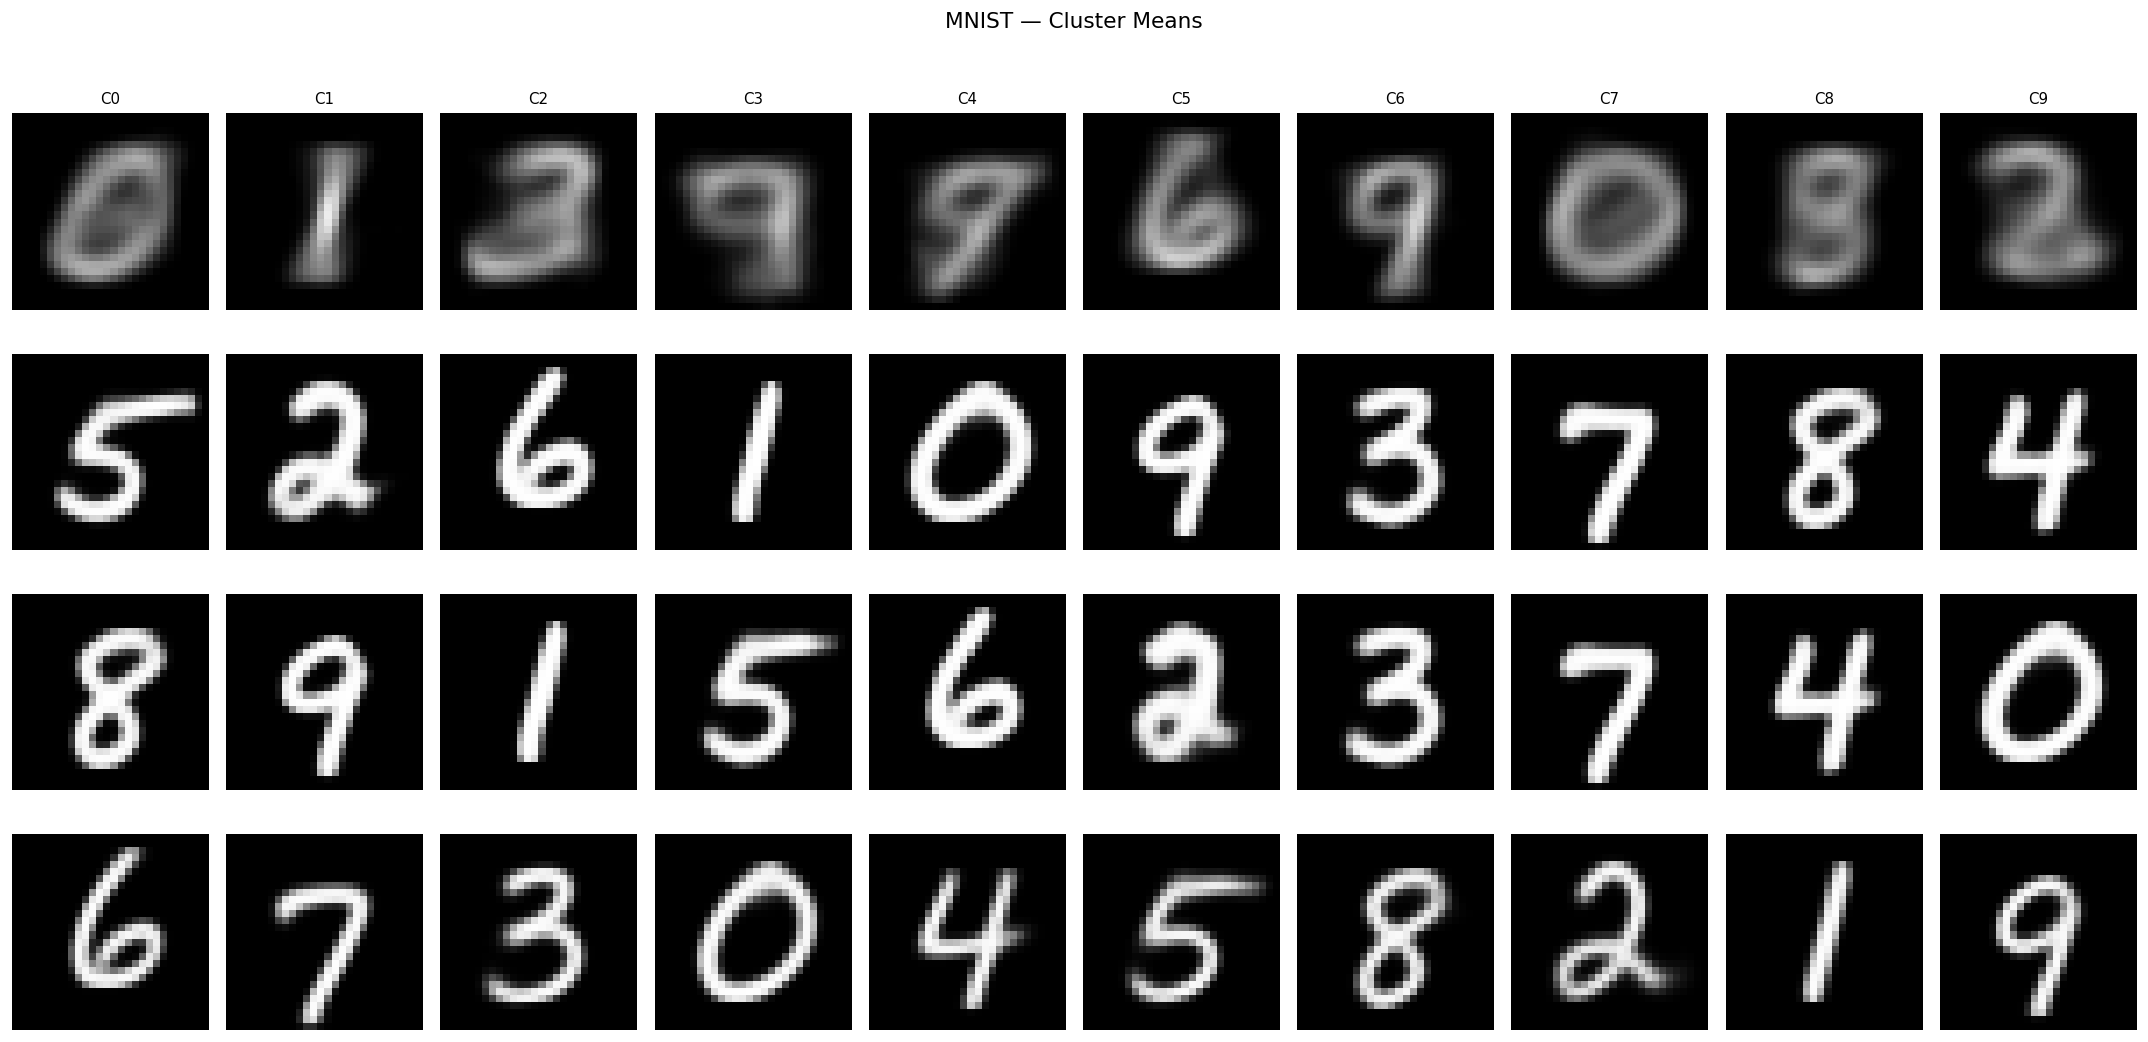

In [4]:
plot_cluster_means_grid(results, MODEL_ORDER, device, title='MNIST — Cluster Means')

## 4. Cluster Purity (Ours)

Per-cluster breakdown showing which digit dominates each cluster and the purity ratio.

In [5]:
import pandas as pd
if 'ours' in results:
    r = results['ours']
    purity_df = compute_cluster_purity_table(
        r['labels'], r['cluster_labels'], r['num_clusters'], dataset_info['class_names']
    )
    # Display without .style accessor to avoid Jinja2 dependency issues
    pd.set_option('display.float_format', '{:.2%}'.format)
    display(purity_df)
    pd.reset_option('display.float_format')

,Cluster,Count,Dominant,Purity,0,1,2,3,4,5,6,7,8,9
0,0,945,6,97.88%,2,2,0,0,6,4,925,0,6,0
1,1,909,7,97.69%,1,0,5,3,1,0,0,888,3,8
2,2,1104,3,88.41%,1,2,7,976,0,54,2,1,38,23
3,3,992,0,97.58%,968,0,9,0,1,2,4,1,1,6
4,4,974,4,97.23%,0,2,1,0,947,0,3,11,3,7
5,5,860,5,95.81%,3,1,0,11,0,824,15,0,3,3
6,6,950,8,95.68%,1,4,8,8,1,5,5,2,909,7
7,7,1138,2,87.96%,4,9,1001,10,2,1,2,101,5,3
8,8,1121,1,99.46%,0,1115,0,0,0,0,1,2,0,3
9,9,1007,9,94.24%,0,0,1,2,24,2,1,22,6,949


## 5. Cluster Samples

Change `CLUSTER_IDX` below and re-run the cell to browse samples from different clusters.


Baseline GMM — Cluster 0 (993 samples)


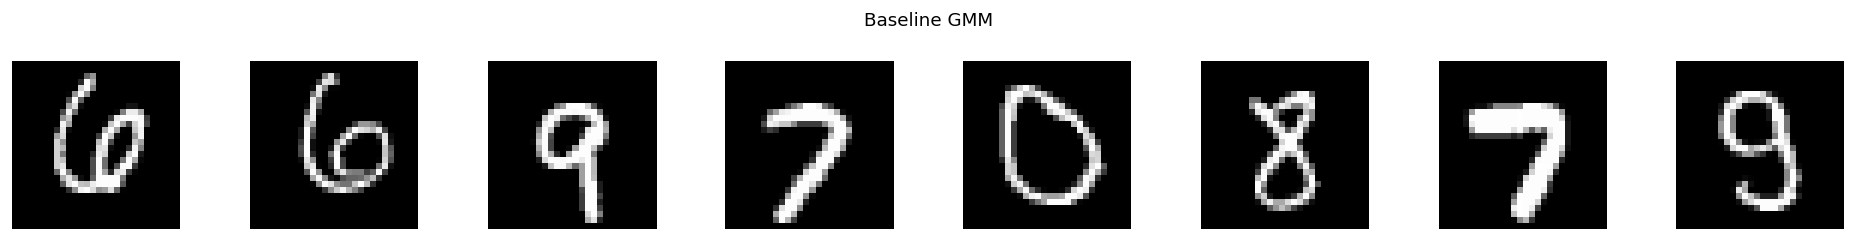


VAE-GMM — Cluster 0 (697 samples)


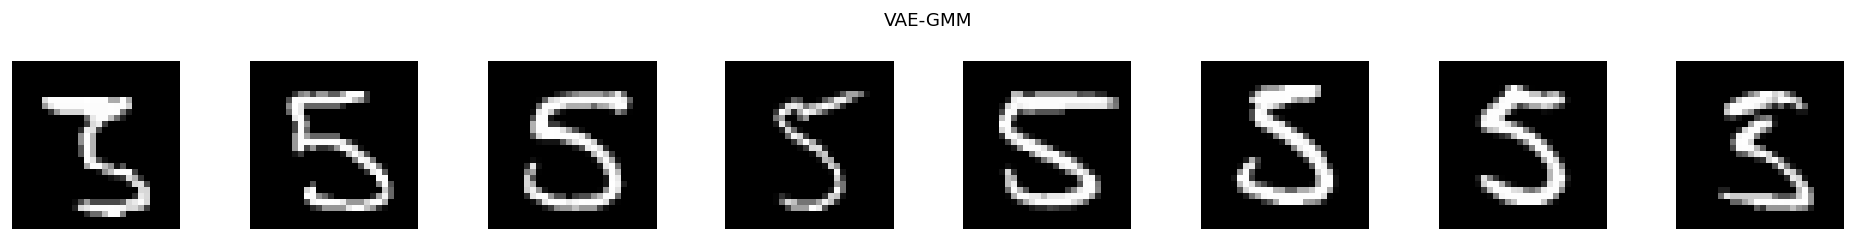


Diffusion-VAE — Cluster 0 (841 samples)


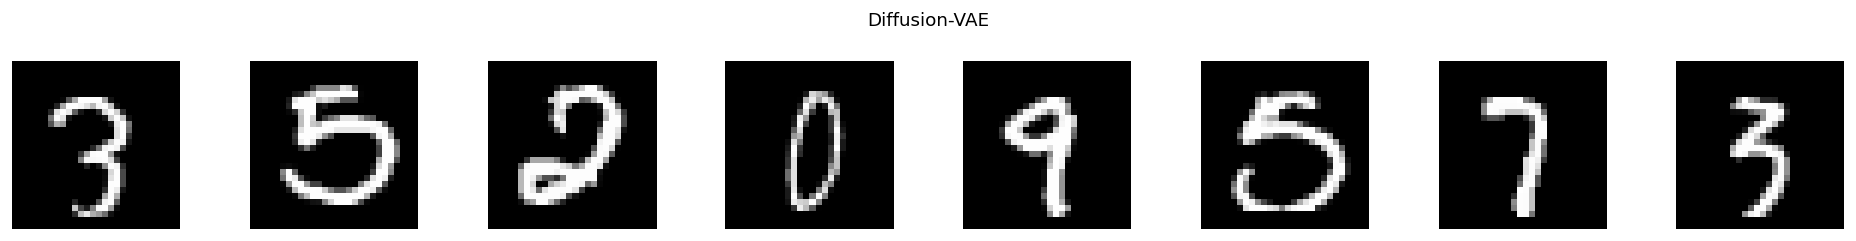


Ours — Cluster 0 (945 samples)


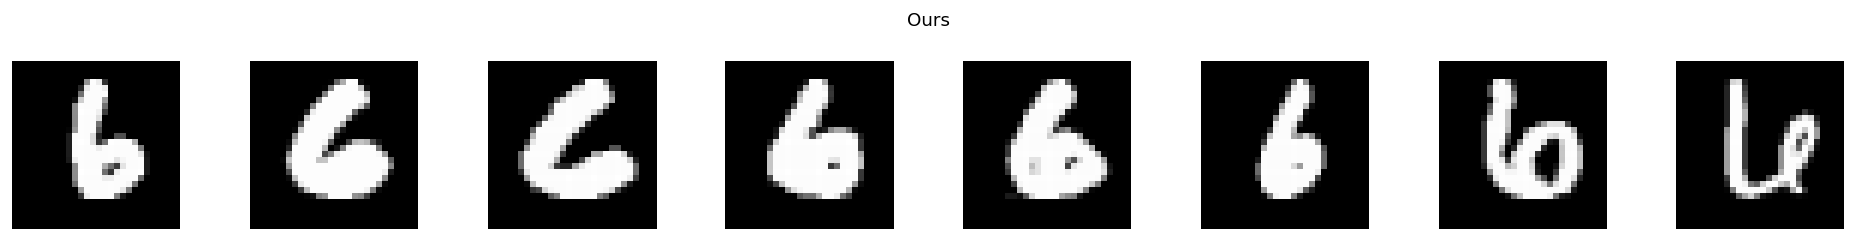

In [6]:
CLUSTER_IDX = 0  # <-- Change this value (0-9) and re-run

plot_all_models_cluster_samples(results, MODEL_ORDER, CLUSTER_IDX, n_samples=8)

## Analysis

**Key observations:**

- **Baseline GMM** operates in pixel space (784D) and produces blurry centroids, achieving the lowest performance. The high dimensionality makes GMM fitting difficult.

- **VAE-GMM** learns a compact latent space where GMM clustering is more effective. Cluster means are recognizable digits, showing the VAE decoder generates coherent prototypes.

- **Diffusion-VAE** applies a latent denoiser on top of VAE-GMM. The denoised latent codes can improve cluster separation, though the improvement depends on the denoising timestep.

- **Ours** achieves the best clustering metrics by using manifold-aware EM with heat-kernel graph medoid selection. The cluster prototypes are the sharpest and most representative.